In [53]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from utils import parse_latencies, parse_power_log

In [3]:
DATA_PATH = Path('../../raw_data/power_profile_model_loading')
DELAY = 1 # delay introduced in seconds between inference cycles

In [4]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4186729.598605433


## Resnet18

In this section, we will analyse the power consumption of Resnet18 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [9]:
model_name = 'resnet18'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
resnet18_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
resnet18_latency_data = parse_latencies(data)

with open((DATA_PATH/model_name/'resnet18_tensorrt.json'), 'r') as fp:
    data = json.load(fp)
resnet18_data = data

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 30.99it/s]


In [10]:
print(f"Number of power entries for {model_name}: {len(resnet18_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(resnet18_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(resnet18_latency_data)}")

Number of power entries for resnet18: 2400943
Number of TensorRT layers in resnet18: 26
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

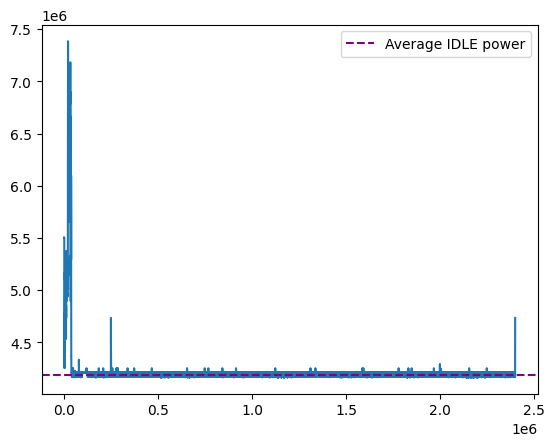

In [7]:
plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [8]:
from utils import plot_inference_cycle_power

### Observations


In [22]:
def get_power_index(power_data, timestamp):
    index = 0
    while True:
        power_timestamp = power_data[index][0]
        if power_timestamp > timestamp:
            return index
        index += 1

In [23]:
experiment_start_time = datetime.strptime(resnet18_data['timestamp'], "%Y%m%d-%H%M%S")
exp_start_time_index = get_power_index(resnet18_power_data, experiment_start_time)

model_load_start_time = datetime.strptime(resnet18_data['model_load'][0], "%Y%m%d-%H%M%S")
model_load_start_index = get_power_index(resnet18_power_data, model_load_start_time)
model_load_end_time = datetime.strptime(resnet18_data['model_load'][1], "%Y%m%d-%H%M%S")
model_load_end_index = get_power_index(resnet18_power_data, model_load_end_time)

warmup_start_time = datetime.strptime(resnet18_data['warmup'][0], "%Y%m%d-%H%M%S")
warmup_start_index = get_power_index(resnet18_power_data, warmup_start_time)
warmup_end_time = datetime.strptime(resnet18_data['warmup'][1], "%Y%m%d-%H%M%S")
warmup_end_index = get_power_index(resnet18_power_data, warmup_end_time)

47.0


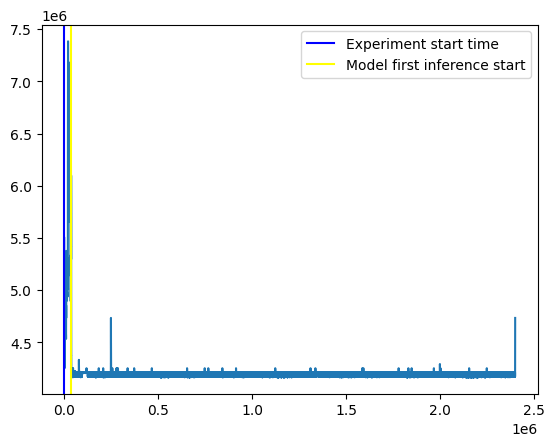

In [56]:
# Time taken to compile the TensorRT model from PyTorch model
print((model_load_start_time - experiment_start_time).total_seconds())

plt.plot([power for (timestamp, power) in resnet18_power_data])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model first inference start')
plt.legend()

0:00:47


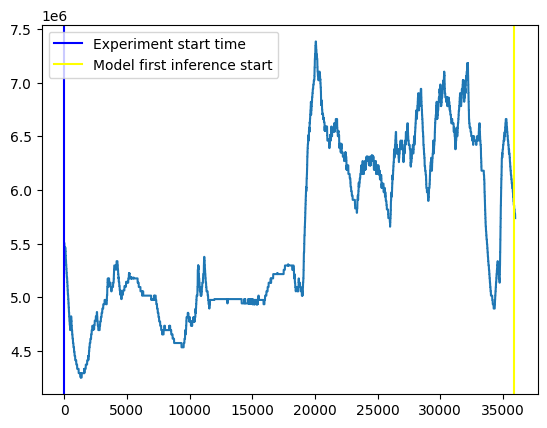

In [50]:
# Time taken to compile the TensorRT model from PyTorch model
print(model_load_start_time - experiment_start_time)

plt.plot(range(0, model_load_start_index+100), [power for (timestamp, power) in resnet18_power_data[:model_load_start_index+100]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model first inference start')
plt.legend()

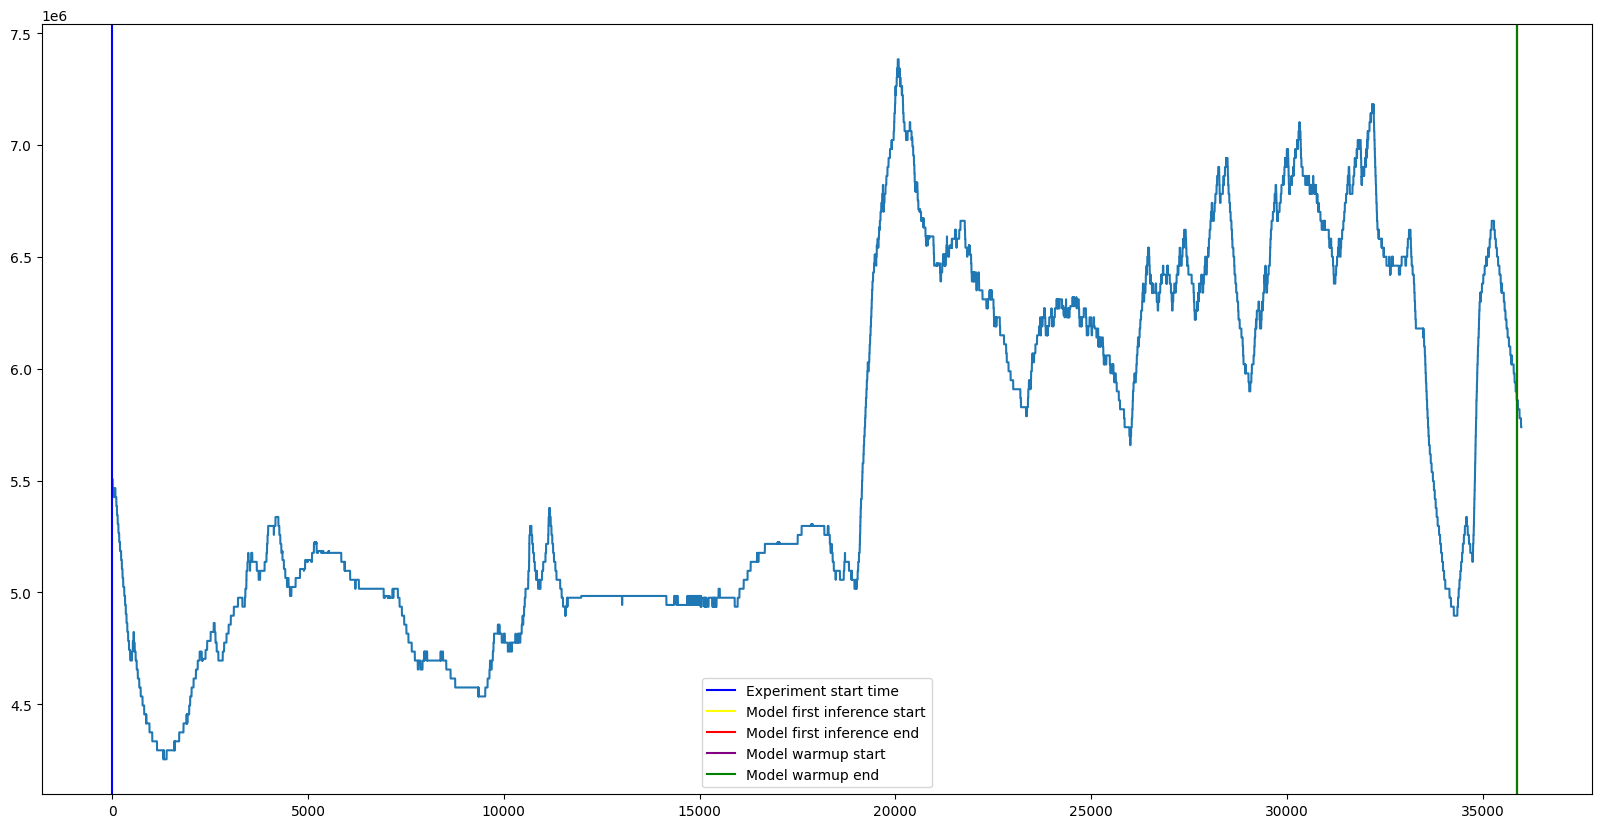

In [36]:
plt.figure(figsize=(20, 10))
plt.plot([power for (timestamp, power) in resnet18_power_data[:warmup_end_index+100]])
plt.axvline(exp_start_time_index, color='blue', label='Experiment start time')
plt.axvline(model_load_start_index, color='yellow', label='Model first inference start')
plt.axvline(model_load_end_index, color='red', label='Model first inference end')
plt.axvline(warmup_start_index, color='purple', label='Model warmup start')
plt.axvline(warmup_end_index, color='green', label='Model warmup end')
plt.legend()

2025-01-21 11:00:11.114939 -> 2025-01-21 11:00:11.115958
2025-01-21 11:00:12.115958
Time taken by inference cycle 100: 0:00:00.001019
Iteration: 100, Power index: 123122 -> 123122
123906


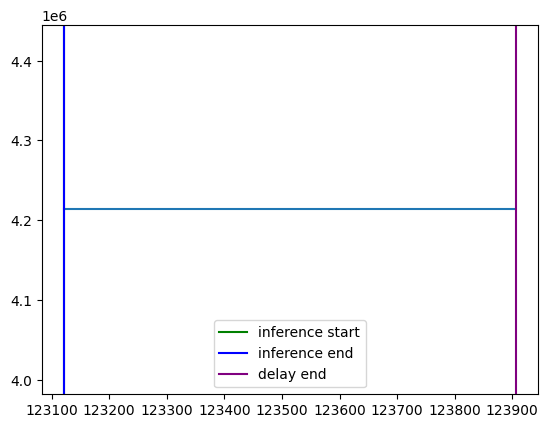

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:12.118592 -> 2025-01-21 11:00:12.119537
2025-01-21 11:00:13.119537
Time taken by inference cycle 101: 0:00:00.000945
Iteration: 101, Power index: 123907 -> 123909
124692


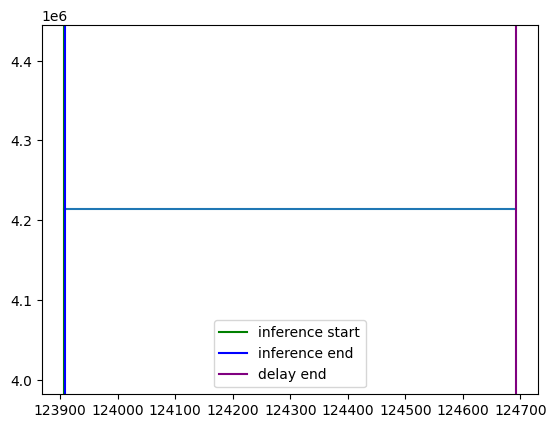

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:13.122185 -> 2025-01-21 11:00:13.123170
2025-01-21 11:00:14.123170
Time taken by inference cycle 102: 0:00:00.000985
Iteration: 102, Power index: 124693 -> 124693
125477


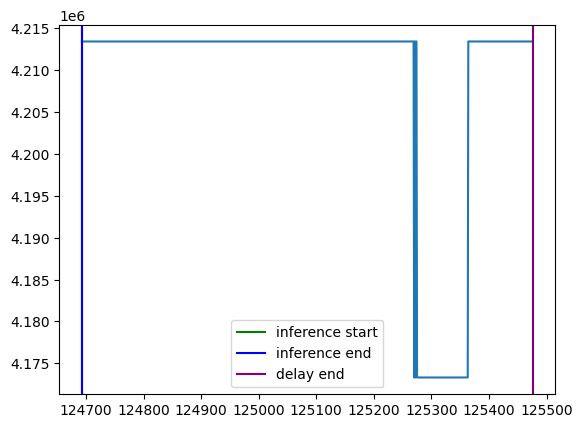

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:14.125779 -> 2025-01-21 11:00:14.126769
2025-01-21 11:00:15.126769
Time taken by inference cycle 103: 0:00:00.000990
Iteration: 103, Power index: 125478 -> 125480
126263


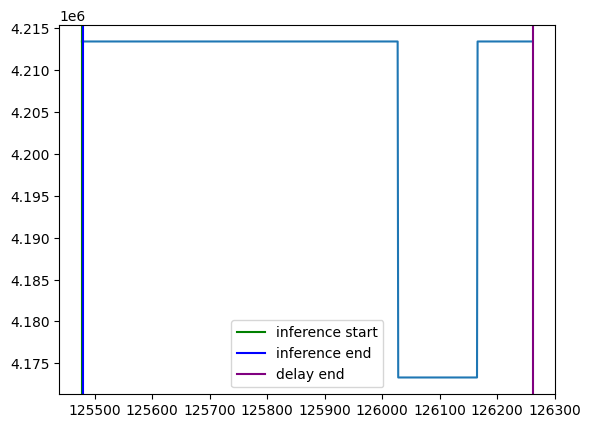

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:15.129345 -> 2025-01-21 11:00:15.130335
2025-01-21 11:00:16.130335
Time taken by inference cycle 104: 0:00:00.000990
Iteration: 104, Power index: 126264 -> 126266
127048


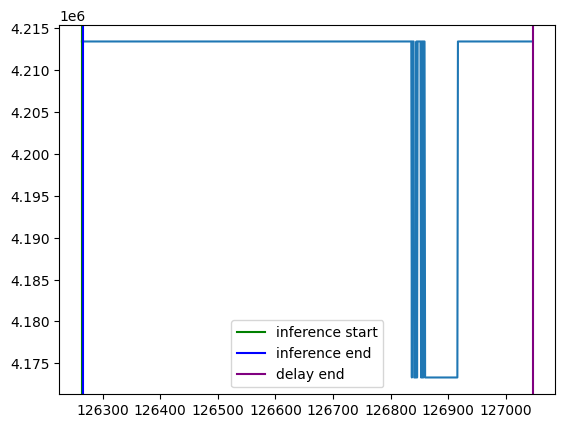

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:16.132895 -> 2025-01-21 11:00:16.133883
2025-01-21 11:00:17.133883
Time taken by inference cycle 105: 0:00:00.000988
Iteration: 105, Power index: 127049 -> 127051
127834


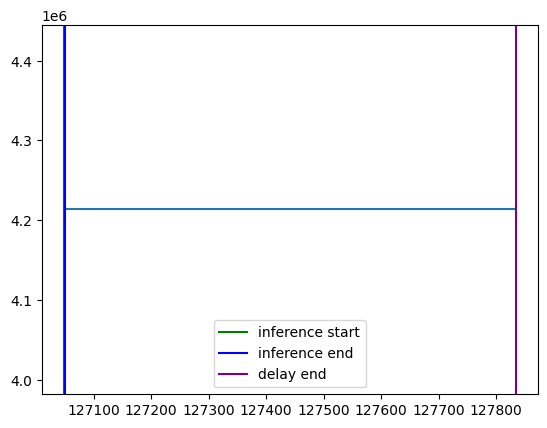

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:17.136507 -> 2025-01-21 11:00:17.137482
2025-01-21 11:00:18.137482
Time taken by inference cycle 106: 0:00:00.000975
Iteration: 106, Power index: 127835 -> 127835
128619


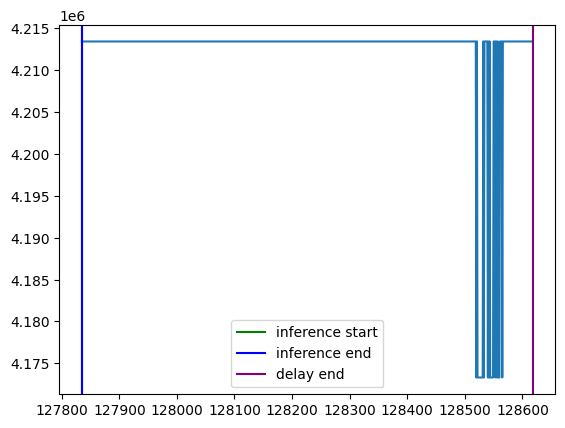

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:18.140377 -> 2025-01-21 11:00:18.141352
2025-01-21 11:00:19.141352
Time taken by inference cycle 107: 0:00:00.000975
Iteration: 107, Power index: 128620 -> 128622
129405


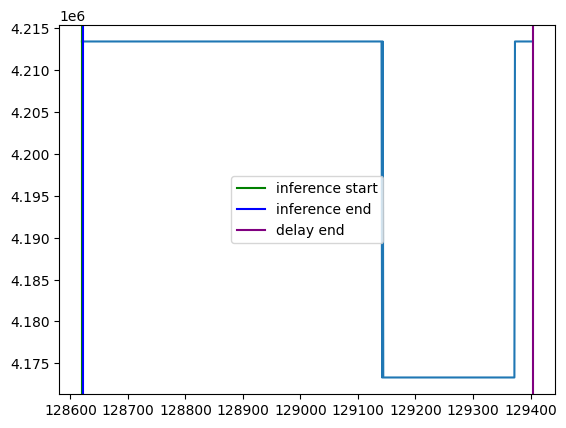

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:19.144239 -> 2025-01-21 11:00:19.145226
2025-01-21 11:00:20.145226
Time taken by inference cycle 108: 0:00:00.000987
Iteration: 108, Power index: 129406 -> 129408
130191


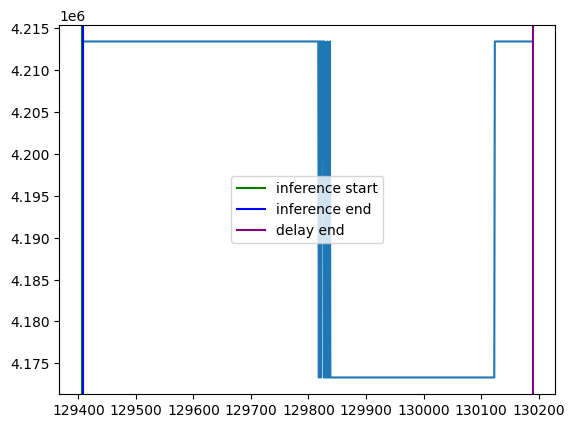

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:20.148414 -> 2025-01-21 11:00:20.149397
2025-01-21 11:00:21.149397
Time taken by inference cycle 109: 0:00:00.000983
Iteration: 109, Power index: 130193 -> 130193
130977


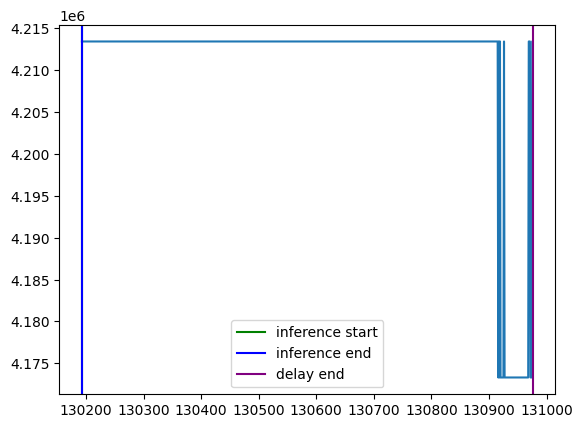

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:21.152269 -> 2025-01-21 11:00:21.153248
2025-01-21 11:00:22.153248
Time taken by inference cycle 110: 0:00:00.000979
Iteration: 110, Power index: 130978 -> 130980
131763


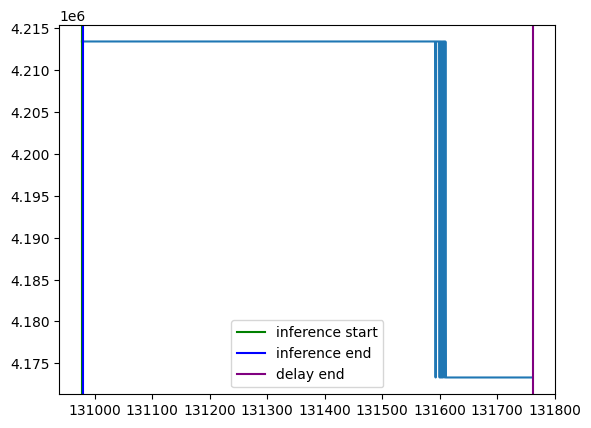

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:22.156977 -> 2025-01-21 11:00:22.157961
2025-01-21 11:00:23.157961
Time taken by inference cycle 111: 0:00:00.000984
Iteration: 111, Power index: 131765 -> 131765
132549


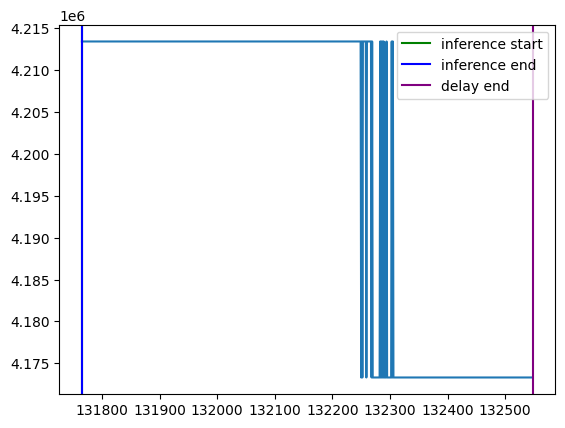

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:23.160288 -> 2025-01-21 11:00:23.161272
2025-01-21 11:00:24.161272
Time taken by inference cycle 112: 0:00:00.000984
Iteration: 112, Power index: 132550 -> 132552
133334


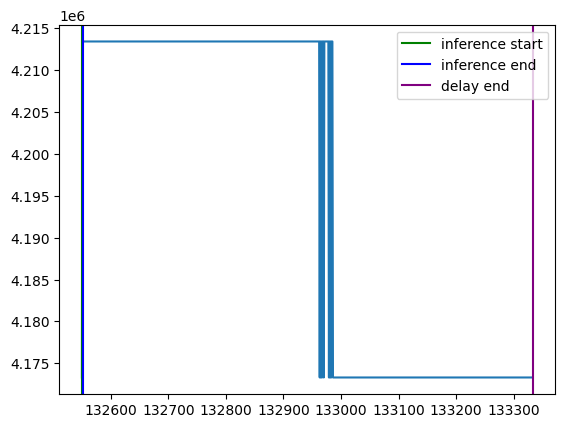

Power values:
Inference start: 4173312.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:24.164127 -> 2025-01-21 11:00:24.165108
2025-01-21 11:00:25.165108
Time taken by inference cycle 113: 0:00:00.000981
Iteration: 113, Power index: 133336 -> 133336
134120


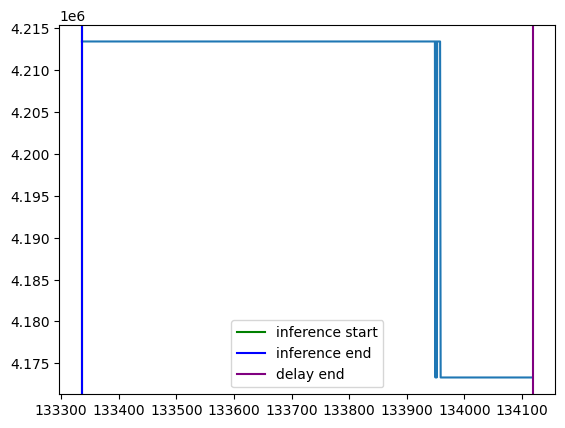

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------
2025-01-21 11:00:25.167915 -> 2025-01-21 11:00:25.168885
2025-01-21 11:00:26.168885
Time taken by inference cycle 114: 0:00:00.000970
Iteration: 114, Power index: 134121 -> 134123
134905


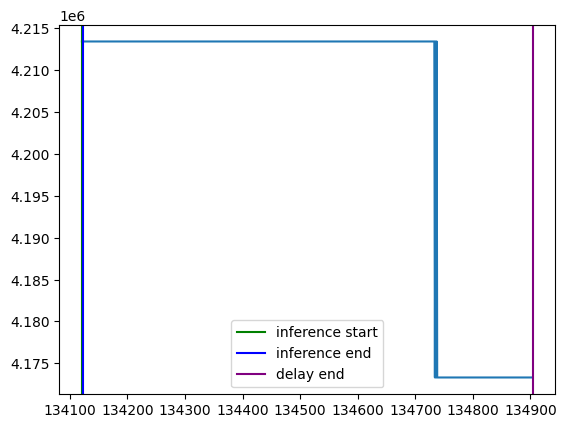

Power values:
Inference start: 4213440.0
Inference end: 4213440.0
Delay end: 4173312.0
----------------------------------------------------------------------------------------------------


In [48]:
for i in range(100, 115):
    plot_inference_cycle_power(i, resnet18_power_data, resnet18_latency_data, DELAY)

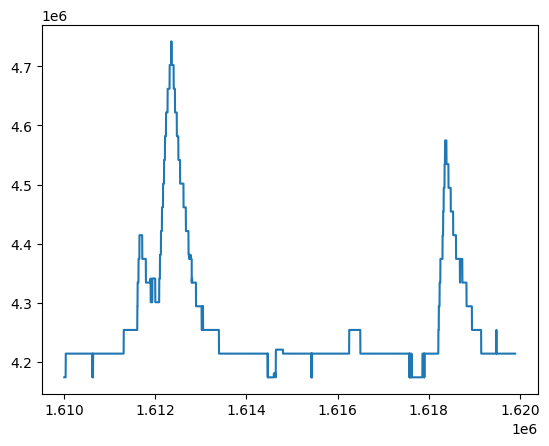

In [9]:
plt.plot(range(1610000, 1619900), [power for (timestamp, power) in resnet18_power_data[1610000:1619900]])

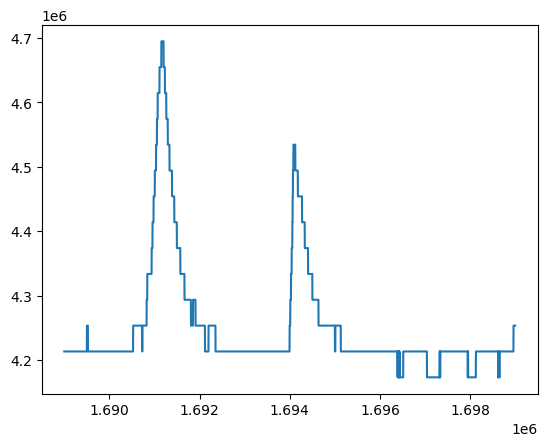

In [10]:
plt.plot(range(1689000, 1699000), [power for (timestamp, power) in resnet18_power_data[1689000:1699000]])

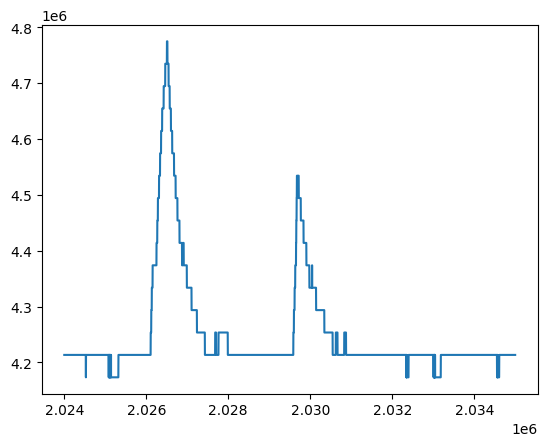

In [11]:
plt.plot(range(2024000, 2035000), [power for (timestamp, power) in resnet18_power_data[2024000:2035000]])

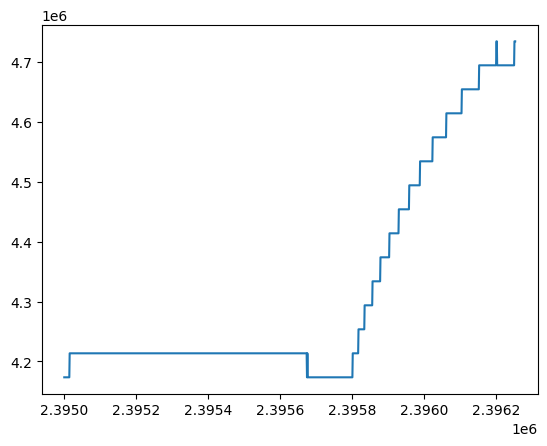

In [12]:
plt.plot(range(2395000, 2396253), [power for (timestamp, power) in resnet18_power_data[2395000:2396253]])